# ***`Libraries`***

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ***`Read Data`***

In [20]:
df = pd.read_excel('Preprocessed Dataset.xlsx').drop('Unnamed: 0', axis=1)
df.head()

,Followers,Total Revenue,Years Joined,Rating Quality,Good Review,Med Review,Bad Review
0,0.060135,0.008283,1.806134,0.453583,0.631159,1.618767,1.080557
1,-0.071209,-0.047449,-1.814746,0.037897,-0.497662,1.196371,0.308262
2,-0.009052,0.008283,0.599174,0.424516,0.641790,-0.172147,1.292087
3,-0.046442,0.008283,0.599174,-0.066678,-0.096943,0.975558,1.761924
4,-0.072807,-0.053651,-0.607786,0.144730,0.344560,-0.269972,0.509950


# ***`Grid Search for Optimal Number of Cluster and Best Parameters`***

In [21]:
import itertools
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Define parameter grids for each clustering algorithm
param_grid_kmeans = {
    'n_clusters': range(3, 11),
    'init': ['k-means++', 'random']
}

param_grid_agglomerative = {
    'n_clusters': range(3, 11),
    'linkage': ['ward', 'complete', 'average', 'single']
}

param_grid_gmm = {
    'n_components': range(3, 11),
    'covariance_type': ['spherical', 'tied', 'diag', 'full']
}

# Store results
grid_search_results = []

# ---------------------------
# Grid Search for K-Means
# ---------------------------
for n_clusters, init in itertools.product(param_grid_kmeans['n_clusters'], param_grid_kmeans['init']):
    kmeans = KMeans(
        n_clusters=n_clusters,
        init=init,
        random_state=42
    )
    labels = kmeans.fit_predict(df)
    silhouette = silhouette_score(df, labels)

    # Append results: (Algorithm, #clusters, Linkage/CovType, silhouette)
    grid_search_results.append(
        ("KMeans", n_clusters, init, silhouette)
    )

# ---------------------------
# Grid Search for Agglomerative Clustering
# ---------------------------
for (n_clusters, linkage) in itertools.product(
    param_grid_agglomerative['n_clusters'],
    param_grid_agglomerative['linkage']
):
    agglo = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage
    )
    labels = agglo.fit_predict(df)
    silhouette = silhouette_score(df, labels)

    grid_search_results.append(
        ("Agglomerative", n_clusters, linkage, silhouette)
    )

# ---------------------------
# Grid Search for GMM
# ---------------------------
for (n_components, covariance_type) in itertools.product(
    param_grid_gmm['n_components'],
    param_grid_gmm['covariance_type']
):
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=42
    )
    labels = gmm.fit_predict(df)
    silhouette = silhouette_score(df, labels)

    grid_search_results.append(
        ("GMM", n_components, covariance_type, silhouette)
    )

# Convert results to DataFrame
df_grid_search_results = pd.DataFrame(
    grid_search_results,
    columns=['Algorithm', 'Clusters/Components', 'Linkage/Covariance', 'Silhouette Score']
)

print(df_grid_search_results)
best_results = df_grid_search_results.loc[df_grid_search_results.groupby("Algorithm")["Silhouette Score"].idxmax()]
print(best_results)

   Algorithm  Clusters/Components Linkage/Covariance  Silhouette Score
0     KMeans                    3          k-means++          0.308657
1     KMeans                    3             random          0.308657
2     KMeans                    4          k-means++          0.300983
3     KMeans                    4             random          0.300786
4     KMeans                    5          k-means++          0.309982
..       ...                  ...                ...               ...
75       GMM                    9               full         -0.033127
76       GMM                   10          spherical          0.240430
77       GMM                   10               tied          0.193135
78       GMM                   10               diag         -0.039760
79       GMM                   10               full         -0.052735

[80 rows x 4 columns]
        Algorithm  Clusters/Components Linkage/Covariance  Silhouette Score
18  Agglomerative                    3           

# ***`K-Means`***

In [22]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42)
kmeanlabels = kmeans.fit_predict(df)

silhouette_avg = silhouette_score(df, kmeanlabels)
print(f"Silhouette Score: {silhouette_avg}")

dbi_score = davies_bouldin_score(df, kmeanlabels)
print(f"Davies-Bouldin Index (DBI): {dbi_score}")

chi_score = calinski_harabasz_score(df, kmeanlabels)
print(f"Calinski-Harabasz Index (CHI): {chi_score}")

Silhouette Score: 0.3099823789945206
Davies-Bouldin Index (DBI): 1.1184574726173662
Calinski-Harabasz Index (CHI): 1013.3883218713236


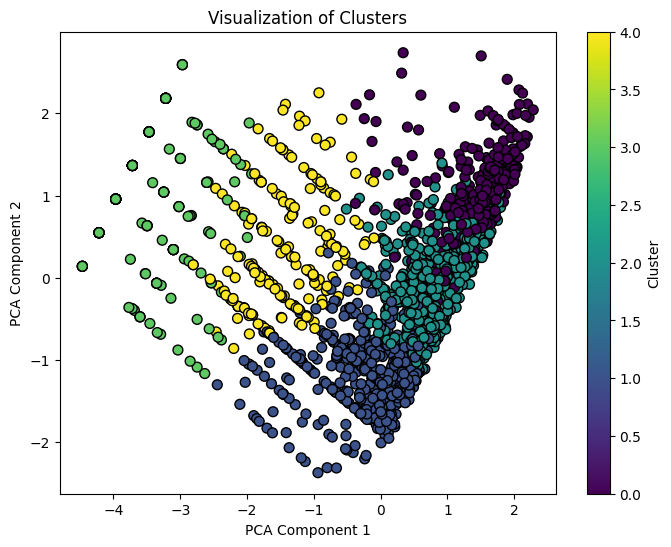

In [23]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

# Create a scatter plot with clusters in different colors
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeanlabels, cmap='viridis', edgecolor='k', s=50)
plt.title('Visualization of Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
# Remove grid lines
plt.grid(False)
plt.show()


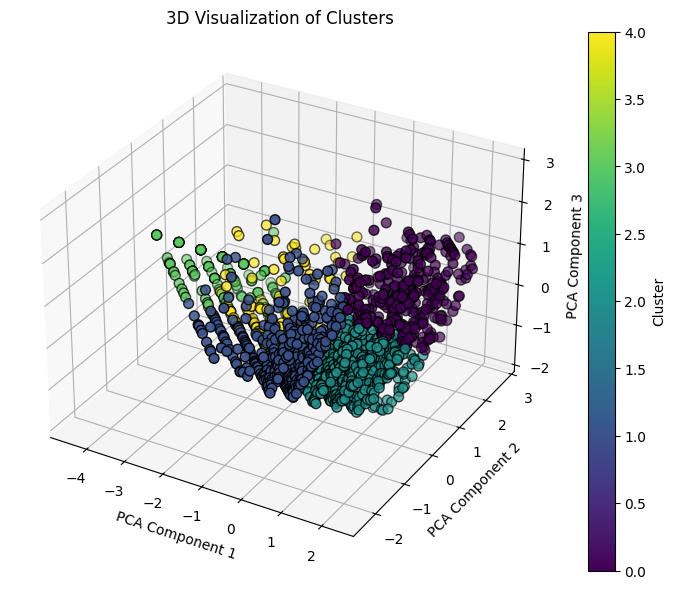

In [24]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions to 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(df)

# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw a 3D scatter plot
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeanlabels, cmap='viridis', edgecolor='k', s=50)

# Set title and labels
ax.set_title('3D Visualization of Clusters')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

# Add a color bar to represent clusters
plt.colorbar(sc, ax=ax, label='Cluster')
plt.grid(False)
plt.show()


# ***`Agglomerative`***

In [25]:
aggclustering = AgglomerativeClustering(n_clusters=3, linkage='average')
agglabels = aggclustering.fit_predict(df)

score = silhouette_score(df, agglabels)
print(f"Silhouette Score: {score}")

dbi_score = davies_bouldin_score(df, agglabels)
print(f"Davies-Bouldin Index (DBI): {dbi_score}")

chi_score = calinski_harabasz_score(df, agglabels)
print(f"Calinski-Harabasz Index (CHI): {chi_score}")

Silhouette Score: 0.341676848402445
Davies-Bouldin Index (DBI): 1.3193835325399252
Calinski-Harabasz Index (CHI): 612.6455430945509


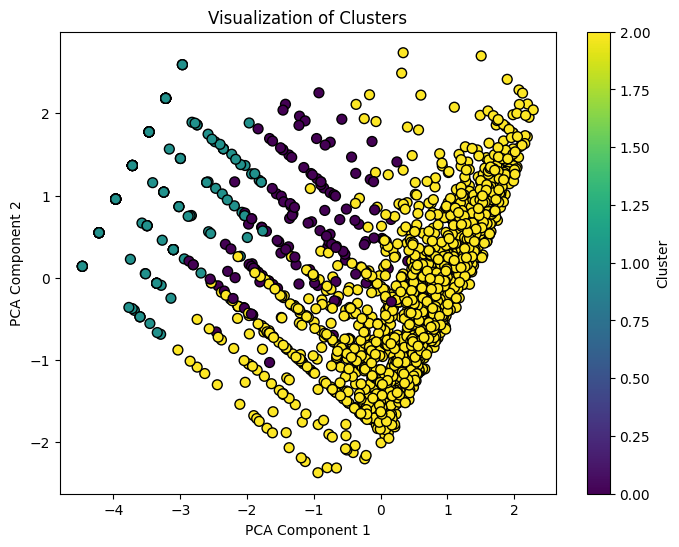

In [26]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

# Create a scatter plot with clusters in different colors
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglabels, cmap='viridis', edgecolor='k', s=50)
plt.title('Visualization of Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
# Remove grid lines
plt.grid(False)
plt.show()


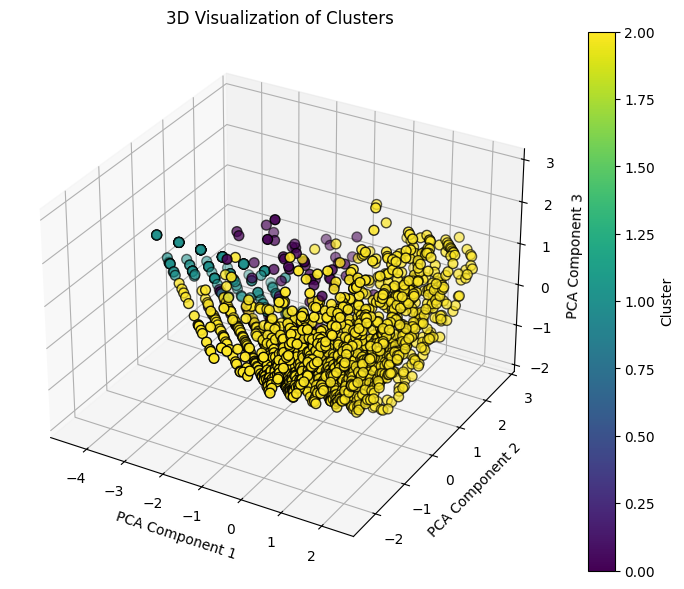

In [27]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions to 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(df)

# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw a 3D scatter plot
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agglabels, cmap='viridis', edgecolor='k', s=50)

# Set title and labels
ax.set_title('3D Visualization of Clusters')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

# Add a color bar to represent clusters
plt.colorbar(sc, ax=ax, label='Cluster')
plt.grid(False)
plt.show()


# ***`Gaussian Mixture Model (GMM)`***

In [28]:
# Use Gaussian Mixture Model (GMM) with 5 clusters
gmm = GaussianMixture(n_components=3, covariance_type='tied', random_state=42)
gmm_labels = gmm.fit_predict(df)

# Calculate evaluation metrics
silhouette_avg = silhouette_score(df, gmm_labels)
print(f"Silhouette Score: {silhouette_avg}")

dbi_score = davies_bouldin_score(df, gmm_labels)
print(f"Davies-Bouldin Index (DBI): {dbi_score}")

chi_score = calinski_harabasz_score(df, gmm_labels)
print(f"Calinski-Harabasz Index (CHI): {chi_score}")


Silhouette Score: 0.2911431947684483
Davies-Bouldin Index (DBI): 1.15915447982278
Calinski-Harabasz Index (CHI): 874.0668010737617


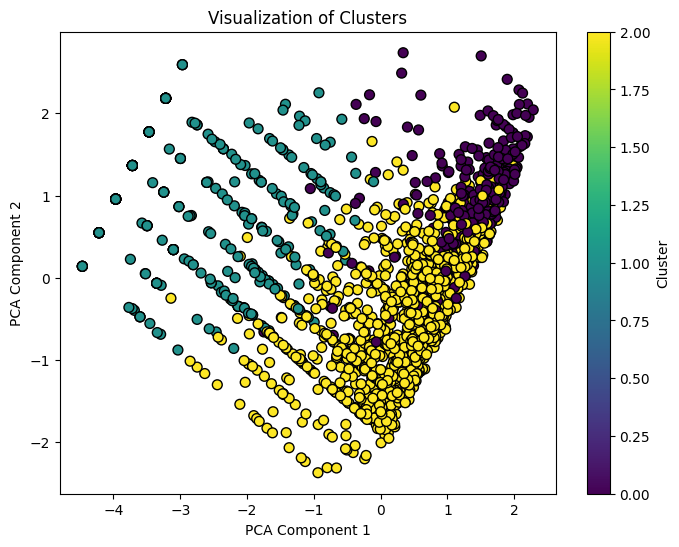

In [29]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

# Create a scatter plot with clusters in different colors
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', edgecolor='k', s=50)
plt.title('Visualization of Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
# Remove grid lines
plt.grid(False)
plt.show()


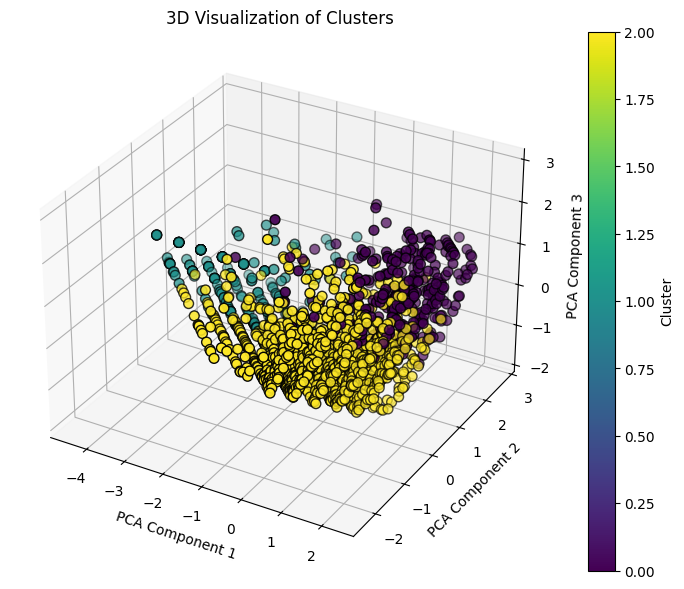

In [32]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions to 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(df)

# Create a 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Draw a 3D scatter plot
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=gmm_labels, cmap='viridis', edgecolor='k', s=50)

# Set title and labels
ax.set_title('3D Visualization of Clusters')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

# Add a color bar to represent clusters
plt.colorbar(sc, ax=ax, label='Cluster')
plt.grid(False)
plt.show()
